In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Objective function
def f(x):
    x1, x2 = x[0], x[1]
    return (x1 - 1.2)**2 + 2*(x2 - 2.5)**2 + 0.4*x1*x2

# Gradient vector
def grad_f(x):
    x1, x2 = x[0], x[1]
    df_dx1 = 2 * (x1 - 1.2) + 0.4 * x2
    df_dx2 = 4 * (x2 - 2.5) + 0.4 * x1
    return np.array([df_dx1, df_dx2])

# Projected gradient descent
def projected_gradient_descent(x_init, projection_fn, lr=0.1, iterations=60):
    x = np.array(x_init, dtype=float)
    history_x = [x.copy()]
    history_f = [f(x)]
    
    for _ in range(iterations):
        # Gradient descent step
        x_unproj = x - lr * grad_f(x)
        # Projection step
        x = projection_fn(x_unproj)
        
        history_x.append(x.copy())
        history_f.append(f(x))
        
    return np.array(history_x), np.array(history_f)

In [61]:
def project_X1(x):
    """Projection onto X1"""
    x1_proj = np.clip(x[0], 0.5, 2.5)
    x2_proj = np.clip(x[1], 0.5, 3.5)
    return np.array([x1_proj, x2_proj])

In [62]:
def project_X2(x):
    """
    Projection onto X2
    """
    y1, y2 = x[0], x[1]
    # If the point is already within the feasible region, return it directly
    if y1 >= 0.5 and y2 >= y1:
        return np.array([y1, y2])
    
    # Calculate the projection onto boundary ray 1 (x1 = 0.5 and x2 >= 0.5)
    p1 = np.array([0.5, max(0.5, y2)])
    
    # Calculate the projection onto boundary ray 2 (x1 = x2 and x1 >= 0.5)
    m = (y1 + y2) / 2.0
    p2 = np.array([max(0.5, m), max(0.5, m)])
    
    # Compare the distances from the two projection points to the original point (y1, y2)
    dist1 = (p1[0] - y1)**2 + (p1[1] - y2)**2
    dist2 = (p2[0] - y1)**2 + (p2[1] - y2)**2
    
    # Return the closer projection point
    if dist1 < dist2:
        return p1
    else:
        return p2

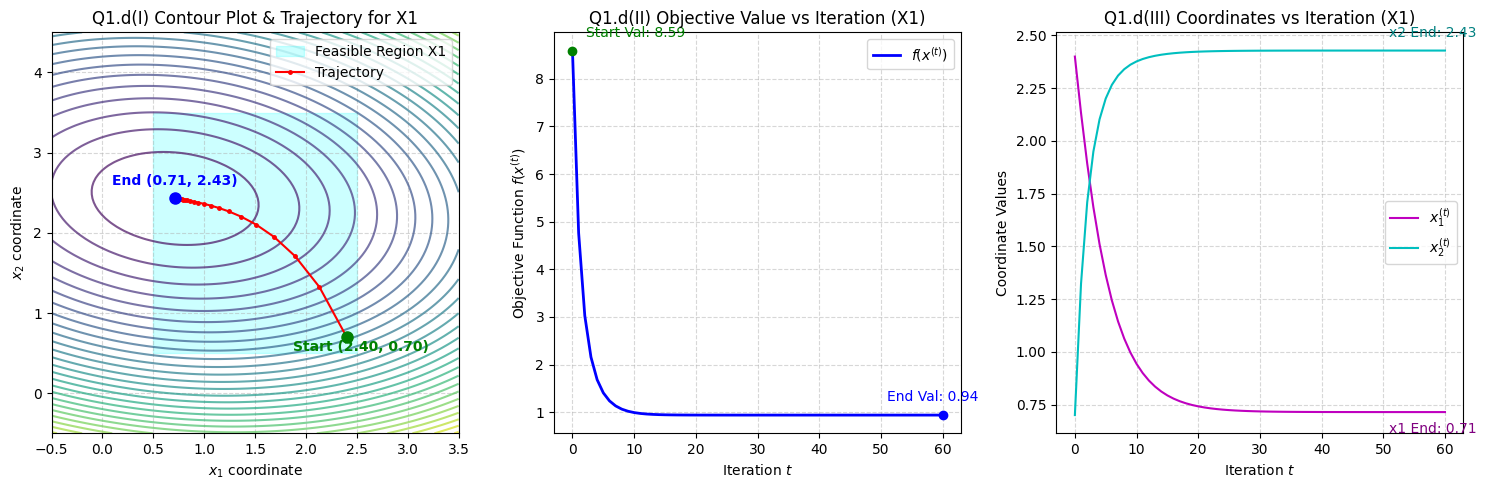

In [63]:
x0 = [2.4, 0.7]
iterations = 60
lr = 0.1

history_x_X1, history_f_X1 = projected_gradient_descent(x0, project_X1, lr=lr, iterations=iterations)


plt.figure(figsize=(15, 5))

# Figure I: Contour of objective function, feasible region X1 and trajectory
plt.subplot(1, 3, 1)
x1_grid = np.linspace(-0.5, 3.5, 100)
x2_grid = np.linspace(-0.5, 4.5, 100)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
Z_mesh = (X1_mesh - 1.2)**2 + 2*(X2_mesh - 2.5)**2 + 0.4*X1_mesh*X2_mesh

plt.contour(X1_mesh, X2_mesh, Z_mesh, levels=30, cmap='viridis', alpha=0.7)
# Boundary of feasible region X1
rect = plt.Rectangle((0.5, 0.5), 2.0, 3.0, fill=True, color='cyan', alpha=0.2, label='Feasible Region X1')
plt.gca().add_patch(rect)
plt.plot(history_x_X1[:, 0], history_x_X1[:, 1], 'r.-', label='Trajectory', markersize=5)

# Start and end points
start_x1 = history_x_X1[0]
end_x1 = history_x_X1[-1]
plt.plot(*start_x1, 'go', markersize=8) 
plt.plot(*end_x1, 'bo', markersize=8)   
plt.annotate(f'Start (2.40, 0.70)', start_x1, textcoords="offset points", xytext=(10,-10), ha='center', color='green', fontweight='bold')
plt.annotate(f'End ({end_x1[0]:.2f}, {end_x1[1]:.2f})', end_x1, textcoords="offset points", xytext=(0,10), ha='center', color='blue', fontweight='bold')

plt.title('Q1.d(I) Contour Plot & Trajectory for X1')
plt.xlabel('$x_1$ coordinate')
plt.ylabel('$x_2$ coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Figure II: Objective function value versus iterations
plt.subplot(1, 3, 2)
plt.plot(range(iterations + 1), history_f_X1, 'b-', label='$f(x^{(t)})$', linewidth=2)
plt.plot(0, history_f_X1[0], 'go')
plt.plot(iterations, history_f_X1[-1], 'bo')
plt.annotate(f'Start Val: {history_f_X1[0]:.2f}', (0, history_f_X1[0]), textcoords="offset points", xytext=(10,10), color='green')
plt.annotate(f'End Val: {history_f_X1[-1]:.2f}', (iterations, history_f_X1[-1]), textcoords="offset points", xytext=(-40,10), color='blue')
plt.title('Q1.d(II) Objective Value vs Iteration (X1)')
plt.xlabel('Iteration $t$')
plt.ylabel('Objective Function $f(x^{(t)})$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Figure III: x1 and x2 coordinates versus iterations
plt.subplot(1, 3, 3)
plt.plot(range(iterations + 1), history_x_X1[:, 0], 'm-', label='$x_1^{(t)}$')
plt.plot(range(iterations + 1), history_x_X1[:, 1], 'c-', label='$x_2^{(t)}$')
plt.annotate(f'x1 End: {end_x1[0]:.2f}', (iterations, end_x1[0]), textcoords="offset points", xytext=(-40,-15), color='purple')
plt.annotate(f'x2 End: {end_x1[1]:.2f}', (iterations, end_x1[1]), textcoords="offset points", xytext=(-40,10), color='teal')
plt.title('Q1.d(III) Coordinates vs Iteration (X1)')
plt.xlabel('Iteration $t$')
plt.ylabel('Coordinate Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

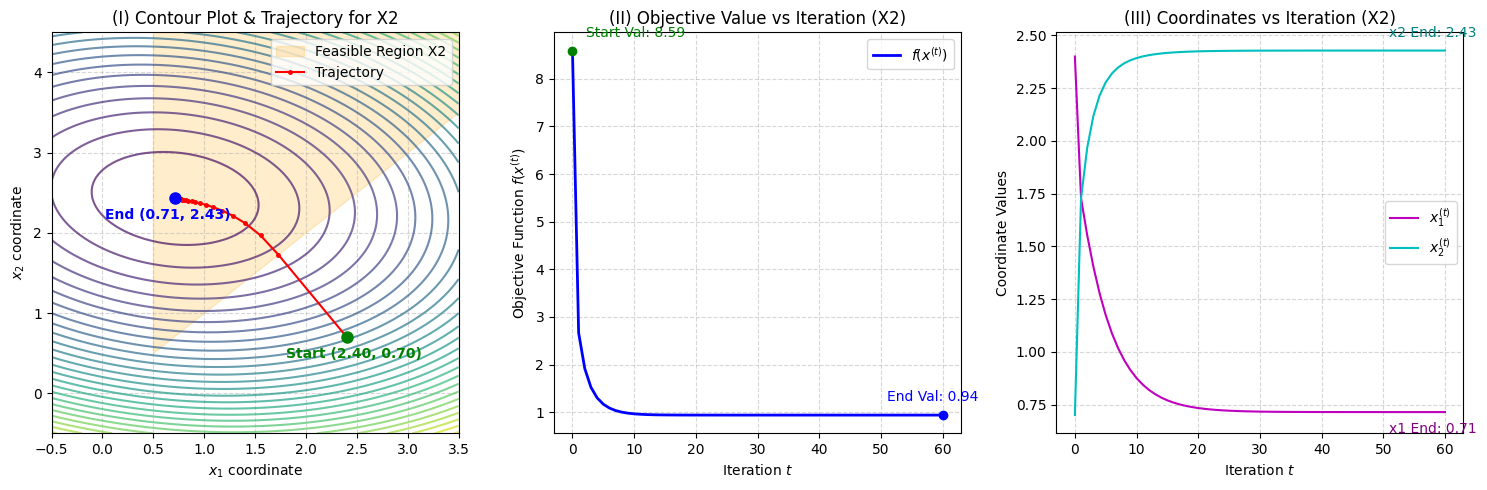

In [64]:
history_x_X2, history_f_X2 = projected_gradient_descent(x0, project_X2, lr=lr, iterations=iterations)

plt.figure(figsize=(15, 5))

# Figure I: Contour of objective function, feasible region X2 and trajectory
plt.subplot(1, 3, 1)
plt.contour(X1_mesh, X2_mesh, Z_mesh, levels=30, cmap='viridis', alpha=0.7)

# Draw feasible region
fill_x1 = np.array([0.5, 0.5, 4.5])
fill_x2 = np.array([0.5, 4.5, 4.5])
plt.fill(fill_x1, fill_x2, color='orange', alpha=0.2, label='Feasible Region X2')

plt.plot(history_x_X2[:, 0], history_x_X2[:, 1], 'r.-', label='Trajectory', markersize=5)

start_x2 = history_x_X2[0]
end_x2 = history_x_X2[-1]
plt.plot(*start_x2, 'go', markersize=8)
plt.plot(*end_x2, 'bo', markersize=8)
plt.annotate(f'Start (2.40, 0.70)', start_x2, textcoords="offset points", xytext=(5,-15), ha='center', color='green', fontweight='bold')
plt.annotate(f'End ({end_x2[0]:.2f}, {end_x2[1]:.2f})', end_x2, textcoords="offset points", xytext=(-5,-15), ha='center', color='blue', fontweight='bold')

plt.title('(I) Contour Plot & Trajectory for X2')
plt.xlabel('$x_1$ coordinate')
plt.ylabel('$x_2$ coordinate')
plt.xlim(-0.5, 3.5)
plt.ylim(-0.5, 4.5)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Figure II: Objective function value versus iterations
plt.subplot(1, 3, 2)
plt.plot(range(iterations + 1), history_f_X2, 'b-', label='$f(x^{(t)})$', linewidth=2)
plt.plot(0, history_f_X2[0], 'go')
plt.plot(iterations, history_f_X2[-1], 'bo')
plt.annotate(f'Start Val: {history_f_X2[0]:.2f}', (0, history_f_X2[0]), textcoords="offset points", xytext=(10,10), color='green')
plt.annotate(f'End Val: {history_f_X2[-1]:.2f}', (iterations, history_f_X2[-1]), textcoords="offset points", xytext=(-40,10), color='blue')
plt.title('(II) Objective Value vs Iteration (X2)')
plt.xlabel('Iteration $t$')
plt.ylabel('Objective Function $f(x^{(t)})$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Figure III: x1 and x2 coordinates versus iterations
plt.subplot(1, 3, 3)
plt.plot(range(iterations + 1), history_x_X2[:, 0], 'm-', label='$x_1^{(t)}$')
plt.plot(range(iterations + 1), history_x_X2[:, 1], 'c-', label='$x_2^{(t)}$')
plt.annotate(f'x1 End: {end_x2[0]:.2f}', (iterations, end_x2[0]), textcoords="offset points", xytext=(-40,-15), color='purple')
plt.annotate(f'x2 End: {end_x2[1]:.2f}', (iterations, end_x2[1]), textcoords="offset points", xytext=(-40,10), color='teal')
plt.title('(III) Coordinates vs Iteration (X2)')
plt.xlabel('Iteration $t$')
plt.ylabel('Coordinate Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def f(x): return (x[0] - 0.2)**2 + (x[1] - 2)**2
def grad_f(x): return np.array([2*(x[0] - 0.2), 2*(x[1] - 2)])

def g1(x): return 0.5 - x[0]
def grad_g1(x): return np.array([-1.0, 0.0])

def g2(x): return 1.0 - x[0]*x[1]
def grad_g2(x): return np.array([-x[1], -x[0]])

# Gradient of the augmented function F
def grad_F(x, lam1, lam2):
    gf = grad_f(x)
    # Add the corresponding penalty gradient when the constraint is violated (g > 0)
    pen1 = lam1 * grad_g1(x) if g1(x) > 0 else np.array([0.0, 0.0])
    pen2 = lam2 * grad_g2(x) if g2(x) > 0 else np.array([0.0, 0.0])
    return gf + pen1 + pen2

# Gradient descent with fixed penalty method
def penalty_gradient_descent(x_init, lam1, lam2, lr=0.02, iters=100):
    x = np.array(x_init, dtype=float)
    history_x = [x.copy()]
    
    for _ in range(iters):
        gradient = grad_F(x, lam1, lam2)
        x = x - lr * gradient
        history_x.append(x.copy())
        
    return np.array(history_x)


x0_q2 = [1.4, 0.6]
hist_x_small_pen = penalty_gradient_descent(x0_q2, lam1=0.5, lam2=0.5, lr=0.05, iters=100)
hist_x_large_pen = penalty_gradient_descent(x0_q2, lam1=4.0, lam2=4.0, lr=0.01, iters=100) 


In [66]:
# Primal-Dual Iteration
def primal_dual_iteration(x_init, alpha, beta, iters=100):
    x = np.array(x_init, dtype=float)
    # Initialize multipliers to 0
    lam = np.array([0.0, 0.0]) 
    
    history_x = [x.copy()]
    history_lam = [lam.copy()]
    
    for _ in range(iters):
        # Compute gradient of augmented Lagrangian w.r.t. x
        grad_L_x = grad_f(x) + lam[0]*grad_g1(x) + lam[1]*grad_g2(x)
        
        # Update x 
        x_next = x - alpha * grad_L_x
        
        # Update multipliers lam
        lam1_next = max(0.0, lam[0] + beta * g1(x))
        lam2_next = max(0.0, lam[1] + beta * g2(x))
        lam_next = np.array([lam1_next, lam2_next])
        
        x = x_next
        lam = lam_next
        
        history_x.append(x.copy())
        history_lam.append(lam.copy())
        
    return np.array(history_x), np.array(history_lam)

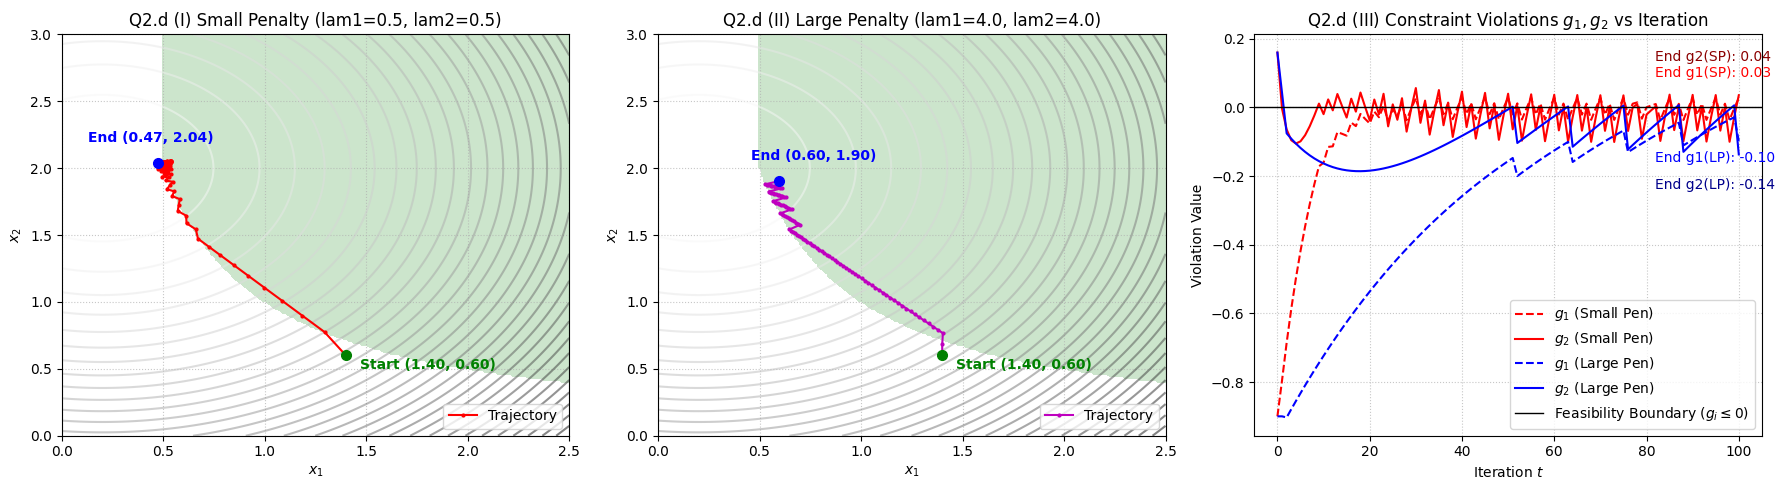

In [67]:
plt.figure(figsize=(18, 5))

x1_grid = np.linspace(0.0, 2.5, 200)
x2_grid = np.linspace(0.0, 3.0, 200)
X1_m, X2_m = np.meshgrid(x1_grid, x2_grid)
Z_f = (X1_m - 0.2)**2 + (X2_m - 2)**2
feasible_mask = (X1_m >= 0.5) & (X1_m * X2_m >= 1.0)

# Figure (I) Trajectory with small penalty weights
plt.subplot(1, 3, 1)
plt.contour(X1_m, X2_m, Z_f, levels=30, cmap='gray_r', alpha=0.5)
plt.contourf(X1_m, X2_m, feasible_mask, levels=[0.5, 1.5], colors=['green'], alpha=0.2)
plt.plot(hist_x_small_pen[:, 0], hist_x_small_pen[:, 1], 'r.-', markersize=4, label='Trajectory')

start_sp = hist_x_small_pen[0]
end_sp = hist_x_small_pen[-1]
plt.plot(*start_sp, 'go', markersize=7)
plt.plot(*end_sp, 'bo', markersize=7)
plt.annotate(f'Start (1.40, 0.60)', start_sp, xytext=(10, -10), textcoords="offset points", color='green', weight='bold')
plt.annotate(f'End ({end_sp[0]:.2f}, {end_sp[1]:.2f})', end_sp, xytext=(-50, 15), textcoords="offset points", color='blue', weight='bold')

plt.title('Q2.d (I) Small Penalty (lam1=0.5, lam2=0.5)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# Figure (II) Trajectory with large penalty weights
plt.subplot(1, 3, 2)
plt.contour(X1_m, X2_m, Z_f, levels=30, cmap='gray_r', alpha=0.5)
plt.contourf(X1_m, X2_m, feasible_mask, levels=[0.5, 1.5], colors=['green'], alpha=0.2)
plt.plot(hist_x_large_pen[:, 0], hist_x_large_pen[:, 1], 'm.-', markersize=4, label='Trajectory')

start_lp = hist_x_large_pen[0]
end_lp = hist_x_large_pen[-1]
plt.plot(*start_lp, 'go', markersize=7)
plt.plot(*end_lp, 'bo', markersize=7)
plt.annotate(f'Start (1.40, 0.60)', start_lp, xytext=(10, -10), textcoords="offset points", color='green', weight='bold')
plt.annotate(f'End ({end_lp[0]:.2f}, {end_lp[1]:.2f})', end_lp, xytext=(-20, 15), textcoords="offset points", color='blue', weight='bold')

plt.title('Q2.d (II) Large Penalty (lam1=4.0, lam2=4.0)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# Figure (III) Constraint violation degree
plt.subplot(1, 3, 3)
g1_vals_sp = [g1(x) for x in hist_x_small_pen]
g2_vals_sp = [g2(x) for x in hist_x_small_pen]
g1_vals_lp = [g1(x) for x in hist_x_large_pen]
g2_vals_lp = [g2(x) for x in hist_x_large_pen]

plt.plot(g1_vals_sp, 'r--', label='$g_1$ (Small Pen)')
plt.plot(g2_vals_sp, 'r-', label='$g_2$ (Small Pen)')
plt.plot(g1_vals_lp, 'b--', label='$g_1$ (Large Pen)')
plt.plot(g2_vals_lp, 'b-', label='$g_2$ (Large Pen)')

plt.axhline(0, color='black', linewidth=1, label=r'Feasibility Boundary ($g_i \leq 0$)')

plt.annotate(f'End g1(SP): {g1_vals_sp[-1]:.2f}', (100, g1_vals_sp[-1]), xytext=(-60, 15), textcoords="offset points", color='red')
plt.annotate(f'End g2(SP): {g2_vals_sp[-1]:.2f}', (100, g2_vals_sp[-1]), xytext=(-60, 25), textcoords="offset points", color='darkred')
plt.annotate(f'End g1(LP): {g1_vals_lp[-1]:.2f}', (100, g1_vals_lp[-1]), xytext=(-60, -15), textcoords="offset points", color='blue')
plt.annotate(f'End g2(LP): {g2_vals_lp[-1]:.2f}', (100, g2_vals_lp[-1]), xytext=(-60, -25), textcoords="offset points", color='darkblue')

plt.title('Q2.d (III) Constraint Violations $g_1, g_2$ vs Iteration')
plt.xlabel('Iteration $t$')
plt.ylabel('Violation Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

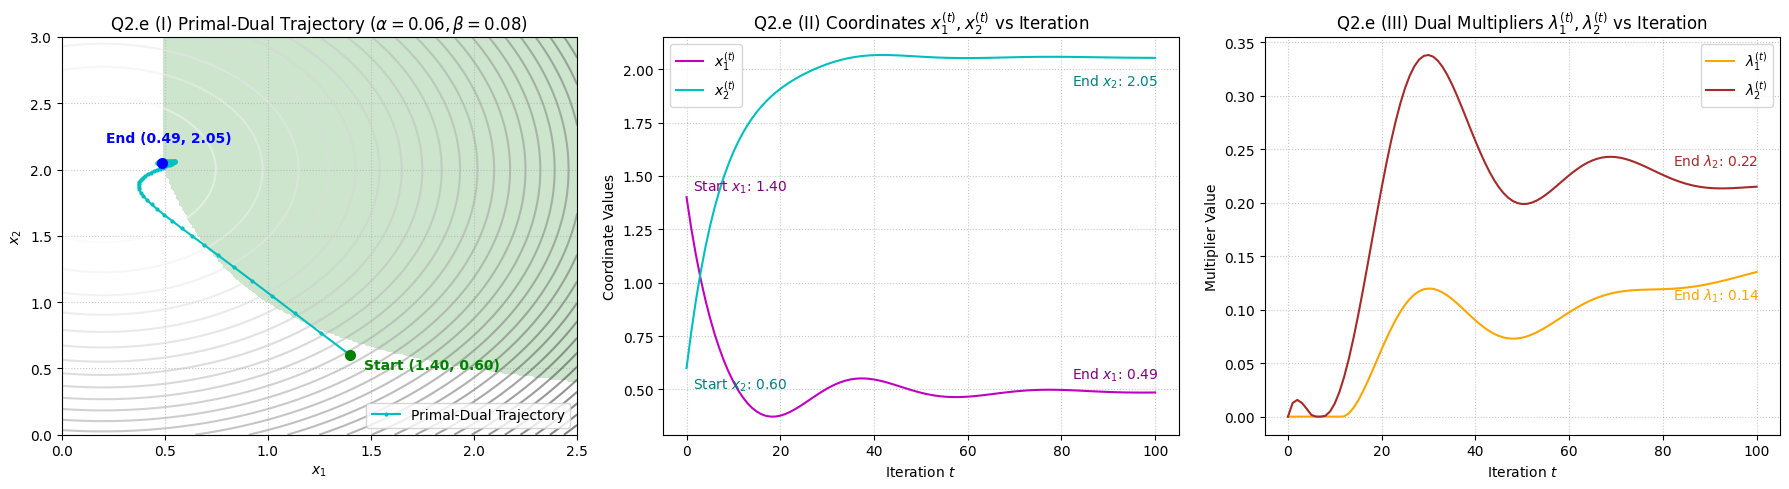

In [68]:
x0_q2 = [1.4, 0.6]  
hist_x_pd, hist_lam_pd = primal_dual_iteration(x0_q2, alpha=0.06, beta=0.08, iters=100)

plt.figure(figsize=(18, 5))

# Figure (I) Primal-Dual Trajectory Plot
plt.subplot(1, 3, 1)
plt.contour(X1_m, X2_m, Z_f, levels=30, cmap='gray_r', alpha=0.5)
plt.contourf(X1_m, X2_m, feasible_mask, levels=[0.5, 1.5], colors=['green'], alpha=0.2)
plt.plot(hist_x_pd[:, 0], hist_x_pd[:, 1], 'c.-', markersize=4, label='Primal-Dual Trajectory')
start_pd = hist_x_pd[0]
end_pd = hist_x_pd[-1]
plt.plot(*start_pd, 'go', markersize=7)
plt.plot(*end_pd, 'bo', markersize=7)
plt.annotate(f'Start (1.40, 0.60)', start_pd, xytext=(10, -10), textcoords="offset points", color='green', weight='bold')
plt.annotate(f'End ({end_pd[0]:.2f}, {end_pd[1]:.2f})', end_pd, xytext=(-40, 15), textcoords="offset points", color='blue', weight='bold')

plt.title('Q2.e (I) Primal-Dual Trajectory ($\\alpha=0.06, \\beta=0.08$)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)


# Figure (II) Primal-Dual Coordinate Trajectory
plt.subplot(1, 3, 2)
plt.plot(hist_x_pd[:, 0], 'm-', label='$x_1^{(t)}$')
plt.plot(hist_x_pd[:, 1], 'c-', label='$x_2^{(t)}$')

plt.annotate(f'Start $x_1$: {hist_x_pd[0, 0]:.2f}', (0, hist_x_pd[0, 0]), xytext=(5, 5), textcoords='offset points', color='purple')
plt.annotate(f'Start $x_2$: {hist_x_pd[0, 1]:.2f}', (0, hist_x_pd[0, 1]), xytext=(5, -15), textcoords='offset points', color='teal')
plt.annotate(f'End $x_1$: {end_pd[0]:.2f}', (100, end_pd[0]), xytext=(-60, 10), textcoords='offset points', color='purple')
plt.annotate(f'End $x_2$: {end_pd[1]:.2f}', (100, end_pd[1]), xytext=(-60, -20), textcoords='offset points', color='teal')

plt.title('Q2.e (II) Coordinates $x_1^{(t)}, x_2^{(t)}$ vs Iteration')
plt.xlabel('Iteration $t$')
plt.ylabel('Coordinate Values')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)


# Figure (III) Primal-Dual Multiplier Trajectory
plt.subplot(1, 3, 3)
plt.plot(hist_lam_pd[:, 0], 'orange', label='$\\lambda_1^{(t)}$')
plt.plot(hist_lam_pd[:, 1], 'brown', label='$\\lambda_2^{(t)}$')

end_lam1, end_lam2 = hist_lam_pd[-1, 0], hist_lam_pd[-1, 1]

plt.annotate(f'End $\\lambda_1$: {end_lam1:.2f}', (100, end_lam1), xytext=(-60, -20), textcoords='offset points', color='orange')
plt.annotate(f'End $\\lambda_2$: {end_lam2:.2f}', (100, end_lam2), xytext=(-60, 15), textcoords='offset points', color='brown')

plt.title('Q2.e (III) Dual Multipliers $\\lambda_1^{(t)}, \\lambda_2^{(t)}$ vs Iteration')
plt.xlabel('Iteration $t$')
plt.ylabel('Multiplier Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def f_q3(x):
    return (x[0] - 1.5)** 2 + (x[1] - 1.2)**2

def grad_f_q3(x):
    return np.array([2*(x[0] - 1.5), 2*(x[1] - 1.2)])

# Feasible region vertex set
VERTICES = np.array([
    [0.5, 0.5],
    [3.0, 0.5],
    [3.0, 1.0],
    [1.0, 3.0],
    [0.5, 3.0]
])

def frank_wolfe(x_init, gamma, iters=60):
    x = np.array(x_init, dtype=float)
    history_x = [x.copy()]
    history_z = [x.copy()] 
    history_f = [f_q3(x)]
    
    for _ in range(iters):
        gradient = grad_f_q3(x)
        
        # Solve linear subproblem: find the vertex with minimal inner product by iteration
        best_val = np.inf
        best_z = None
        for v in VERTICES:
            val = np.dot(gradient, v)
            if val < best_val:
                best_val = val
                best_z = v
                
        # FW update step
        z = best_z
        x = x + gamma * (z - x)
        
        history_x.append(x.copy())
        history_z.append(z.copy())
        history_f.append(f_q3(x))
        
    return np.array(history_x), np.array(history_z), np.array(history_f)

x0_q3 = [2.8, 0.8]
hist_x_fw80, hist_z_fw80, hist_f_fw80 = frank_wolfe(x0_q3, gamma=0.8, iters=60)
hist_x_fw95, hist_z_fw95, hist_f_fw95 = frank_wolfe(x0_q3, gamma=0.95, iters=60)
hist_x_fw10, hist_z_fw10, hist_f_fw10 = frank_wolfe(x0_q3, gamma=0.1, iters=60)

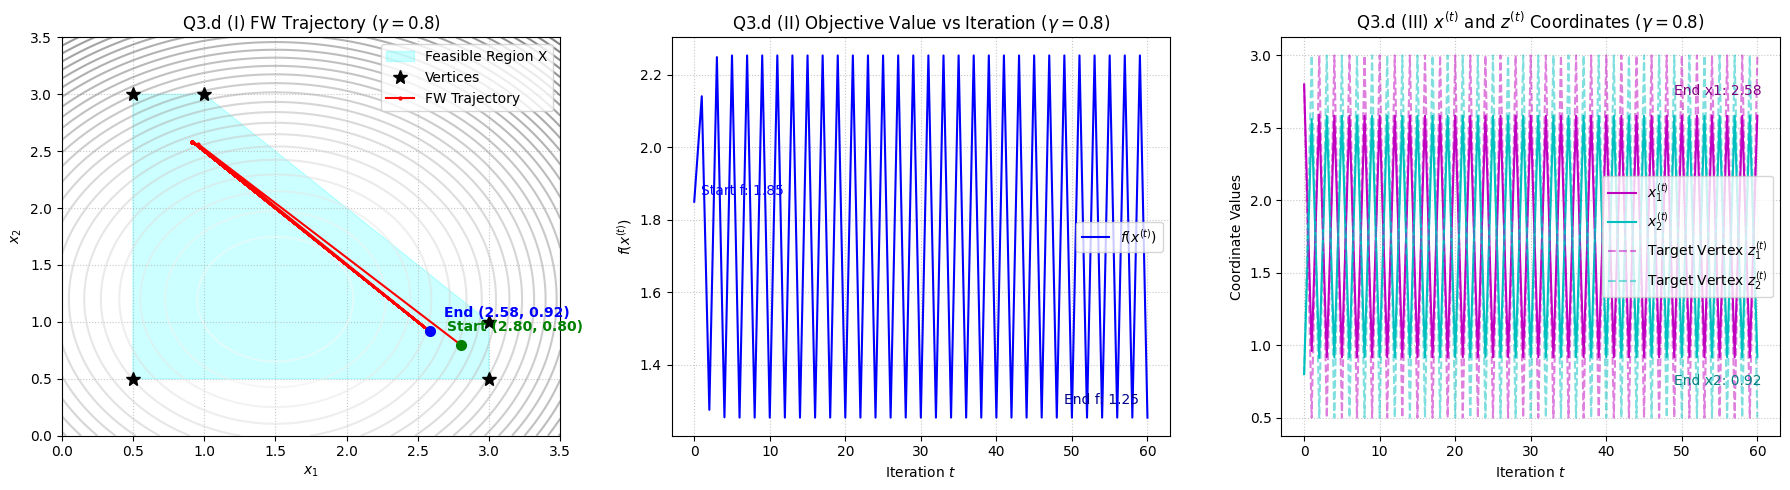

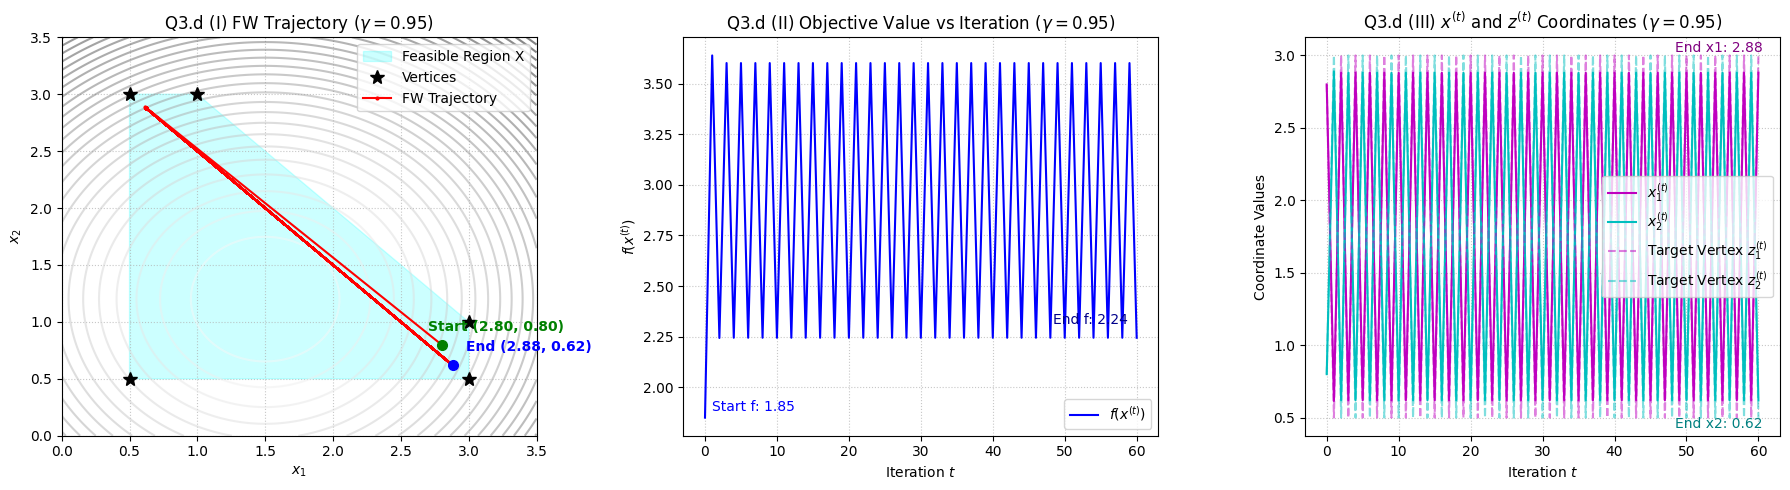

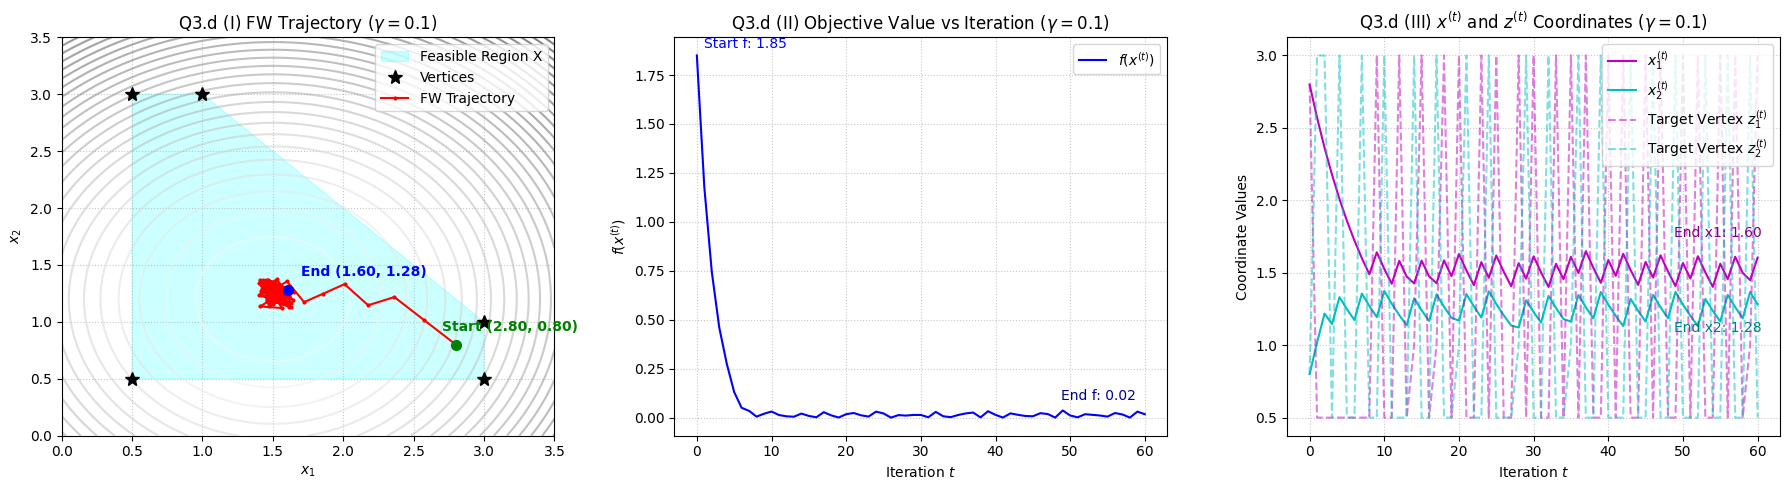

In [70]:
def plot_fw_results(hist_x, hist_z, hist_f, gamma_val):
    plt.figure(figsize=(18, 5))

    x1_grid = np.linspace(0.0, 3.5, 200)
    x2_grid = np.linspace(0.0, 3.5, 200)
    X1_m, X2_m = np.meshgrid(x1_grid, x2_grid)
    Z_f = (X1_m - 1.5)** 2 + (X2_m - 1.2)**2
    
    # Figure (I) Contour, Vertices and Trajectory
    plt.subplot(1, 3, 1)
    plt.contour(X1_m, X2_m, Z_f, levels=30, cmap='gray_r', alpha=0.5)

    polygon = plt.Polygon(VERTICES, closed=True, fill=True, color='cyan', alpha=0.2, label='Feasible Region X')
    plt.gca().add_patch(polygon)
    plt.plot(VERTICES[:, 0], VERTICES[:, 1], 'k*', markersize=10, label='Vertices')
    plt.plot(hist_x[:, 0], hist_x[:, 1], 'r.-', markersize=4, label='FW Trajectory')
    
    start_x = hist_x[0]
    end_x = hist_x[-1]
    plt.plot(*start_x, 'go', markersize=7)
    plt.plot(*end_x, 'bo', markersize=7)
    plt.annotate(f'Start (2.80, 0.80)', start_x, xytext=(-10, 10), textcoords="offset points", color='green', weight='bold')
    plt.annotate(f'End ({end_x[0]:.2f}, {end_x[1]:.2f})', end_x, xytext=(10, 10), textcoords="offset points", color='blue', weight='bold')

    plt.title(f'Q3.d (I) FW Trajectory ($\gamma={gamma_val}$)')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.xlim(0.0, 3.5)
    plt.ylim(0.0, 3.5)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)

    # Figure (II) Objective function value
    plt.subplot(1, 3, 2)
    plt.plot(range(len(hist_f)), hist_f, 'b-', label='$f(x^{(t)})$')
    
    plt.annotate(f'Start f: {hist_f[0]:.2f}', (0, hist_f[0]), xytext=(5, 5), textcoords='offset points', color='blue')
    plt.annotate(f'End f: {hist_f[-1]:.2f}', (len(hist_f)-1, hist_f[-1]), xytext=(-60, 10), textcoords='offset points', color='darkblue')
    
    plt.title(f'Q3.d (II) Objective Value vs Iteration ($\gamma={gamma_val}$)')
    plt.xlabel('Iteration $t$')
    plt.ylabel('$f(x^{(t)})$')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

    # Figure (III) x and z coordinate changes
    plt.subplot(1, 3, 3)
    plt.plot(hist_x[:, 0], 'm-', label='$x_1^{(t)}$')
    plt.plot(hist_x[:, 1], 'c-', label='$x_2^{(t)}$')
    plt.plot(hist_z[:, 0], 'm--', alpha=0.5, label='Target Vertex $z_1^{(t)}$')
    plt.plot(hist_z[:, 1], 'c--', alpha=0.5, label='Target Vertex $z_2^{(t)}$')
    
    plt.annotate(f'End x1: {end_x[0]:.2f}', (len(hist_x)-1, end_x[0]), xytext=(-60, 15), textcoords='offset points', color='purple')
    plt.annotate(f'End x2: {end_x[1]:.2f}', (len(hist_x)-1, end_x[1]), xytext=(-60, -20), textcoords='offset points', color='teal')

    plt.title(f'Q3.d (III) $x^{{(t)}}$ and $z^{{(t)}}$ Coordinates ($\gamma={gamma_val}$)')
    plt.xlabel('Iteration $t$')
    plt.ylabel('Coordinate Values')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Plot results for the three gamma values separately
plot_fw_results(hist_x_fw80, hist_z_fw80, hist_f_fw80, gamma_val=0.8)
plot_fw_results(hist_x_fw95, hist_z_fw95, hist_f_fw95, gamma_val=0.95)
plot_fw_results(hist_x_fw10, hist_z_fw10, hist_f_fw10, gamma_val=0.1)

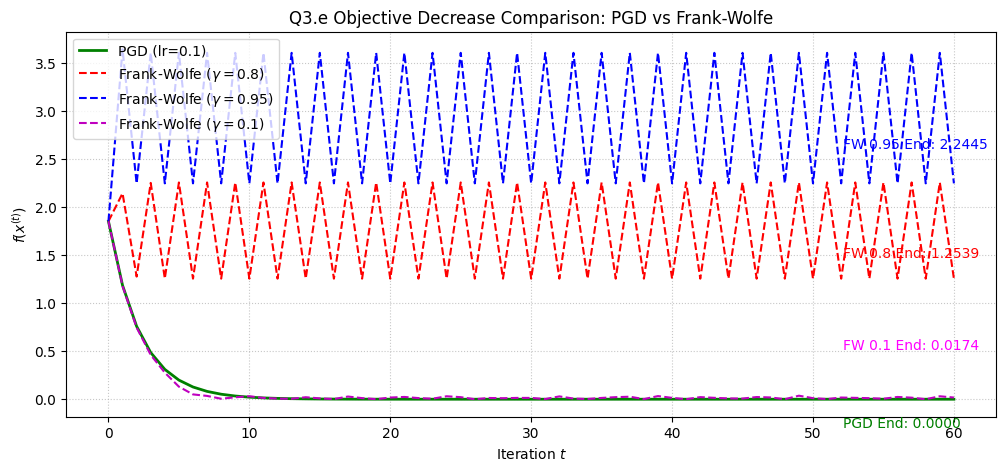

In [71]:
# Projection logic for polygon X
def project_X3(x):

    x_proj = np.clip(x, 0.5, 3.0)
    if x_proj[0] + x_proj[1] > 4.0:
        delta = (x_proj[0] + x_proj[1] - 4.0) / 2.0
        x_proj[0] -= delta
        x_proj[1] -= delta
    return x_proj

def projected_gradient_descent_q3(x_init, lr=0.1, iters=60):
    x = np.array(x_init, dtype=float)
    history_x = [x.copy()]
    history_f = [f_q3(x)]
    
    for _ in range(iters):
        # Gradient descent step
        x_unproj = x - lr * grad_f_q3(x)
        # Projection step
        x = project_X3(x_unproj)
        
        history_x.append(x.copy())
        history_f.append(f_q3(x))
        
    return np.array(history_x), np.array(history_f)

hist_x_pgd, hist_f_pgd = projected_gradient_descent_q3(x0_q3, lr=0.1, iters=60)

plt.figure(figsize=(12, 5))

# Numerical comparison: Objective function descent plot
plt.plot(hist_f_pgd, 'g-', lw=2, label='PGD (lr=0.1)')
plt.plot(hist_f_fw80, 'r--', label='Frank-Wolfe ($\gamma=0.8$)')
plt.plot(hist_f_fw95, 'b--', label='Frank-Wolfe ($\gamma=0.95$)')
plt.plot(hist_f_fw10, 'm--', label='Frank-Wolfe ($\gamma=0.1$)')
plt.annotate(f'PGD End: {hist_f_pgd[-1]:.4f}', (60, hist_f_pgd[-1]), xytext=(-80, -20), textcoords='offset points', color='green')
plt.annotate(f'FW 0.8 End: {hist_f_fw80[-1]:.4f}', (60, hist_f_fw80[-1]), xytext=(-80, 15), textcoords='offset points', color='red')
plt.annotate(f'FW 0.95 End: {hist_f_fw95[-1]:.4f}', (60, hist_f_fw95[-1]), xytext=(-80, 25), textcoords='offset points', color='blue')
plt.annotate(f'FW 0.1 End: {hist_f_fw10[-1]:.4f}', (60, hist_f_fw10[-1]), xytext=(-80, 35), textcoords='offset points', color='magenta')

plt.title('Q3.e Objective Decrease Comparison: PGD vs Frank-Wolfe')
plt.xlabel('Iteration $t$')
plt.ylabel('$f(x^{(t)})$')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()